In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv('./data/train.csv')

In [3]:
data.head(10)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,0,Male,21,1,35.0,0,1-2 Year,Yes,65101.0,124.0,187,0
1,1,Male,43,1,28.0,0,> 2 Years,Yes,58911.0,26.0,288,1
2,2,Female,25,1,14.0,1,< 1 Year,No,38043.0,152.0,254,0
3,3,Female,35,1,1.0,0,1-2 Year,Yes,2630.0,156.0,76,0
4,4,Female,36,1,15.0,1,1-2 Year,No,31951.0,152.0,294,0
5,5,Female,31,1,47.0,1,< 1 Year,No,28150.0,152.0,197,0
6,6,Male,23,1,45.0,1,< 1 Year,No,27128.0,152.0,190,0
7,7,Female,47,1,8.0,0,1-2 Year,Yes,40659.0,26.0,262,1
8,8,Female,26,1,28.0,1,< 1 Year,No,31639.0,152.0,36,0
9,9,Female,66,1,11.0,0,1-2 Year,Yes,2630.0,26.0,125,0


In [6]:
len(data)

11504798

In [3]:
data_train_full = data.head(5000000)

In [8]:
len(data_train)

5000000

Разобьем на тест и валидацию (бустинги учатся довольно долго, поэтому кросс - валидацию делать не будем):

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
data_train, data_val = train_test_split(data_train_full, test_size=0.5, stratify=data_train_full['Response'])

In [6]:
import sys
import os

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

Сделаем колхозно - колотырно, и не будем импортировать функции, а просто скопипастим код, но это тетрадка с экспериментами, поэтому можно:

In [8]:
def fit_preprocessor(train_df):
    """
    Рассчитывает все параметры препроцессинга на обучающих данных
    """
    preprocessor_params = {}

    #print("Обучение препроцессора на train данных...")

    # 1. Медианы для заполнения пропусков в числовых признаках
    numeric_cols = train_df.select_dtypes(include=[np.number]).columns
    medians = {}
    for col in numeric_cols:
        if col not in ['Response']:  # Исключаем целевую переменную
            medians[col] = train_df[col].median()
    preprocessor_params['medians'] = medians
    #print(f"  Рассчитаны медианы для {len(medians)} признаков")

    # 2. LabelEncoders для категориальных признаков
    label_encoders = {}

    # Для бинарных категориальных признаков
    binary_cols = ['Gender', 'Vehicle_Damage']
    for col in binary_cols:
        if col in train_df.columns:
            le = LabelEncoder()
            # Преобразуем в строку и обучаем
            train_df[col] = train_df[col].astype(str)
            le.fit(train_df[col])
            label_encoders[col] = le
            #print(f"  Обучен LabelEncoder для {col}")

    # Для Vehicle_Age - создаем маппинг
    if 'Vehicle_Age' in train_df.columns:
        vehicle_age_mapping = {
            '< 1 Year': 0,
            '1-2 Year': 1,
            '> 2 Years': 2
        }
        preprocessor_params['vehicle_age_mapping'] = vehicle_age_mapping
        #print("  Создан маппинг для Vehicle_Age")

    preprocessor_params['label_encoders'] = label_encoders

    # 3. Квантили для удаления выбросов
    if 'Annual_Premium' in train_df.columns:
        premium_q99 = train_df['Annual_Premium'].quantile(0.999)
        preprocessor_params['premium_q99'] = premium_q99
        #print(f"  Рассчитан 99.9% квантиль для Annual_Premium: {premium_q99}")

    # 4. Границы для Age групп
    if 'Age' in train_df.columns:
        age_bins = [18, 25, 35, 50, 65, 100]
        preprocessor_params['age_bins'] = age_bins
        #print(f"  Определены границы Age групп: {age_bins}")

    # 5. Квантили для Premium_Group
    if 'Annual_Premium' in train_df.columns:
        try:
            # Определяем квантили на train
            premium_quantiles = np.percentile(train_df['Annual_Premium'], [0, 20, 40, 60, 80, 100])
            preprocessor_params['premium_quantiles'] = premium_quantiles.tolist()
            #print(f"  Рассчитаны квантили для Premium_Group: {premium_quantiles}")
        except Exception as e:
            print(f"  Не удалось рассчитать квантили для Premium_Group: {e}")

    # 6. StandardScaler для числовых признаков
    numeric_features = ['Age', 'Annual_Premium', 'Vintage', 'Region_Code', 'Policy_Sales_Channel']
    numeric_features = [col for col in numeric_features if col in train_df.columns]

    if numeric_features:
        scaler = StandardScaler()
        # Преобразуем в float перед обучением
        train_numeric = train_df[numeric_features].astype('float64')
        scaler.fit(train_numeric)
        preprocessor_params['scaler'] = scaler
        preprocessor_params['numeric_features'] = numeric_features
        #print(f"  Обучен StandardScaler для признаков: {numeric_features}")

    return preprocessor_params


# Функция для применения препроцессора (к train и test)
def apply_preprocessor(df, preprocessor_params, is_train=False):
    """
    Применяет параметры препроцессора к данным
    is_train: True если это обучающие данные (для них удаляем выбросы)
    """
    df_processed = df.copy()

    # 1. Заполнение пропусков медианами (из train)
    if 'medians' in preprocessor_params:
        for col, median_val in preprocessor_params['medians'].items():
            if col in df_processed.columns:
                if df_processed[col].isnull().sum() > 0:
                    df_processed.loc[df_processed[col].isnull(), col] = median_val
                    #if is_train:
                        #print(f"  Заполнено пропусков в {col}: {df_processed[col].isnull().sum()}")

    # 2. Кодирование категориальных признаков
    if 'label_encoders' in preprocessor_params:
        for col, le in preprocessor_params['label_encoders'].items():
            if col in df_processed.columns:
                # Преобразуем в строку и применяем кодировку
                df_processed[col] = df_processed[col].astype(str)
                # Используем transform, а не fit_transform!
                try:
                    df_processed[col] = le.transform(df_processed[col])
                except ValueError as e:
                    # Если встретились новые значения в тесте, кодируем как -1
                    #print(f"  Предупреждение: новые значения в {col}, кодируем как -1")
                    # Создаем маппинг известных значений
                    known_values = set(le.classes_)

                    # Функция для преобразования
                    def encode_value(x):
                        return le.transform([x])[0] if x in known_values else -1

                    df_processed[col] = df_processed[col].apply(encode_value)

    # 3. Кодирование Vehicle_Age
    if 'vehicle_age_mapping' in preprocessor_params and 'Vehicle_Age' in df_processed.columns:
        vehicle_age_mapping = preprocessor_params['vehicle_age_mapping']
        df_processed['Vehicle_Age'] = df_processed['Vehicle_Age'].map(vehicle_age_mapping)
        # Заполняем пропуски значением 1 (самое частое)
        if df_processed['Vehicle_Age'].isnull().sum() > 0:
            df_processed.loc[df_processed['Vehicle_Age'].isnull(), 'Vehicle_Age'] = 1

    # 4. Обработка Region_Code и Policy_Sales_Channel
    for col in ['Region_Code', 'Policy_Sales_Channel']:
        if col in df_processed.columns:
            # Преобразуем в строку и извлекаем числа
            df_processed[col] = df_processed[col].astype(str)
            df_processed[col] = df_processed[col].str.extract(r'(\d+)')
            df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
            # Заполняем пропуски медианой из train
            if col in preprocessor_params.get('medians', {}):
                median_val = preprocessor_params['medians'][col]
                df_processed.loc[df_processed[col].isnull(), col] = median_val

    # 5. Удаление выбросов (ТОЛЬКО train!)
    if is_train and 'premium_q99' in preprocessor_params and 'Annual_Premium' in df_processed.columns:
        original_len = len(df_processed)
        premium_q99 = preprocessor_params['premium_q99']
        mask = df_processed['Annual_Premium'] <= premium_q99
        df_processed = df_processed[mask].copy()
        removed_count = original_len - len(df_processed)
        #if removed_count > 0:
            #print(f"  Удалено выбросов из Annual_Premium: {removed_count} строк")

    # 6. Обработка Age (только на train)
    if is_train and 'Age' in df_processed.columns:
        original_len = len(df_processed)
        age_mask = (df_processed['Age'] >= 18) & (df_processed['Age'] <= 100)
        df_processed = df_processed[age_mask].copy()
        removed_count = original_len - len(df_processed)
        #if removed_count > 0:
            #print(f"  Удалено некорректных значений Age: {removed_count} строк")

    # 7. Создание новых признаков
    # Age_Group
    if 'age_bins' in preprocessor_params and 'Age' in df_processed.columns:
        age_bins = preprocessor_params['age_bins']
        df_processed['Age_Group'] = pd.cut(df_processed['Age'],
                                           bins=age_bins,
                                           labels=[0, 1, 2, 3, 4],
                                           include_lowest=True)
        df_processed['Age_Group'] = df_processed['Age_Group'].astype('float64')

    # Premium_Group (используем квантили из train)
    if 'premium_quantiles' in preprocessor_params and 'Annual_Premium' in df_processed.columns:
        premium_quantiles = preprocessor_params['premium_quantiles']
        try:
            df_processed['Premium_Group'] = pd.cut(df_processed['Annual_Premium'],
                                                   bins=premium_quantiles,
                                                   labels=[0, 1, 2, 3, 4],
                                                   include_lowest=True)
            df_processed['Premium_Group'] = df_processed['Premium_Group'].astype('float64')
        except Exception as e:
            print(f"  Не удалось создать Premium_Group: {e}")

    # 8. Удаление ненужных столбцов, id не нужен для обучения
    columns_to_drop = ['id']
    for col in columns_to_drop:
        if col in df_processed.columns:
            df_processed = df_processed.drop(columns=[col])

    # 9. Нормализация числовых признаков
    if 'scaler' in preprocessor_params and 'numeric_features' in preprocessor_params:
        scaler = preprocessor_params['scaler']
        numeric_features = preprocessor_params['numeric_features']

        # Преобразуем в float64
        for col in numeric_features:
            if col in df_processed.columns:
                df_processed[col] = df_processed[col].astype('float64')

        # Применяем скаляр (transform, не fit_transform!)
        normalized_array = scaler.transform(df_processed[numeric_features])
        normalized_df = pd.DataFrame(normalized_array,
                                     columns=numeric_features,
                                     index=df_processed.index)

        for col in numeric_features:
            df_processed[col] = normalized_df[col]

    return df_processed

In [9]:
preprocessor_params = fit_preprocessor(data_train)

In [10]:
train_processed = apply_preprocessor(data_train, preprocessor_params, is_train=True)
val_processed = apply_preprocessor(data_val, preprocessor_params, is_train=False)

In [11]:
from sklearn.metrics import classification_report

In [12]:
from catboost import CatBoostClassifier

In [30]:
train_processed.head(10)

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Age_Group,Premium_Group
3679194,1,0.974498,1,-1.417825,0,2,1,0.525427,-1.598133,0.313926,1,3.0,3.0
324044,0,0.974498,1,-0.339930,1,1,0,0.712758,0.214797,-1.711819,0,3.0,3.0
1501819,1,0.841121,1,-0.262938,0,1,1,0.277978,0.214797,-1.549259,0,3.0,3.0
239906,0,0.174240,1,-0.493915,0,0,0,-1.688939,-2.060615,1.301789,0,2.0,0.0
3893893,1,-0.959458,1,1.122928,0,0,1,0.424179,0.732777,-1.249149,0,0.0,3.0
2764580,0,-1.026146,1,-0.416923,0,0,1,-1.688939,0.825274,0.551513,1,0.0,0.0
32559,1,2.308260,1,0.276010,1,1,0,0.238061,-1.598133,-0.899020,0,4.0,2.0
2755318,1,0.440993,1,0.122025,0,2,1,0.525427,-1.598133,1.126725,1,2.0,3.0
1411204,1,0.641057,1,0.122025,0,1,1,0.660769,-1.598133,-1.624287,1,2.0,3.0
2322583,1,0.507681,1,1.507891,0,1,1,-0.364699,-1.598133,-0.911525,1,2.0,1.0


In [35]:
categorical_features = ['Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Age_Group', 'Premium_Group']

Попробуем Catboost без настроек - хороший бейзлайн:

In [52]:
cb_classifier = CatBoostClassifier(cat_features=categorical_features, auto_class_weights='Balanced', iterations=1000, early_stopping_rounds=100)

In [46]:
X_train = train_processed.drop(['Response'], axis=1)
y_train = train_processed['Response']

In [47]:
X_val = val_processed.drop(['Response'], axis=1)
y_val = val_processed['Response']

In [42]:
X_train[categorical_features].isna().any()

Previously_Insured    False
Vehicle_Age           False
Vehicle_Damage        False
Age_Group             False
Premium_Group         False
dtype: bool

Nan в категориальных колонках нет.

Catboost требует, чтобы категориальные фичи были типа string или int, переведем Age_Group и Premium_Group:

In [48]:
X_train['Age_Group'] = X_train['Age_Group'].astype(int)
X_val['Age_Group'] = X_val['Age_Group'].astype(int)

In [49]:
X_train['Premium_Group'] = X_train['Premium_Group'].astype(int)
X_val['Premium_Group'] = X_val['Premium_Group'].astype(int)

In [53]:
cb_classifier.fit(X_train, y_train, verbose=10)

Learning rate set to 0.29085
0:	learn: 0.5076116	total: 793ms	remaining: 13m 11s
10:	learn: 0.4173619	total: 8.69s	remaining: 13m 1s
20:	learn: 0.4127449	total: 17.1s	remaining: 13m 15s
30:	learn: 0.4103327	total: 26.4s	remaining: 13m 45s
40:	learn: 0.4088805	total: 35.8s	remaining: 13m 57s
50:	learn: 0.4074824	total: 45s	remaining: 13m 57s
60:	learn: 0.4057602	total: 54s	remaining: 13m 50s
70:	learn: 0.4047985	total: 1m 3s	remaining: 13m 49s
80:	learn: 0.4037224	total: 1m 13s	remaining: 13m 48s
90:	learn: 0.4028240	total: 1m 22s	remaining: 13m 43s
100:	learn: 0.4020683	total: 1m 31s	remaining: 13m 34s
110:	learn: 0.4014725	total: 1m 40s	remaining: 13m 28s
120:	learn: 0.4009134	total: 1m 50s	remaining: 13m 22s
130:	learn: 0.4003335	total: 1m 59s	remaining: 13m 11s
140:	learn: 0.3999360	total: 2m 8s	remaining: 13m 3s
150:	learn: 0.3994342	total: 2m 17s	remaining: 12m 55s
160:	learn: 0.3991471	total: 2m 27s	remaining: 12m 47s
170:	learn: 0.3988442	total: 2m 36s	remaining: 12m 38s
180:	le

Classification report на train:

In [54]:
print(classification_report(y_train, cb_classifier.predict(X_train)))

              precision    recall  f1-score   support

           0       0.99      0.71      0.82   2190250
           1       0.31      0.93      0.46    307254

    accuracy                           0.73   2497504
   macro avg       0.65      0.82      0.64   2497504
weighted avg       0.90      0.73      0.78   2497504



Classification report на валидации:

Более развернутая оценка:

In [55]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

In [56]:
import matplotlib.pyplot as plt

In [57]:
def plot_roc_pr_curves(y_scores, y_test, model_name):
    """
        Plots ROC and PR curves by y_scores (if possiable predictions
        probabilities, otherwise somewhat measure of confidene).
        Model name used for plots
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    #ROC curve and AUC-ROC
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    ax1.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
             label='Random classifier')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'ROC Curve - {model_name}')
    ax1.legend(loc="lower right")
    ax1.grid(True, alpha=0.3)

    #PR curve and AUC-PR
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    pr_auc = average_precision_score(y_test, y_scores)

    ax2.plot(recall, precision, color='green', lw=2,
             label=f'PR curve (AUC = {pr_auc:.3f})')

    #Line for random classifier
    random_precision = len(y_test[y_test == 1]) / len(y_test)
    ax2.axhline(y=random_precision, color='red', linestyle='--',
                label=f'Random classifier (AP = {random_precision:.3f})')

    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title(f'Precision-Recall Curve - {model_name}')
    ax2.legend(loc="lower left")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return roc_auc, pr_auc

def calculate_auc_scores(y_scores, y_test):
    """
        Calculates AUC-ROC and AUC-PR
    """

    #AUC-ROC
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    #AUC-PR
    pr_auc = average_precision_score(y_test, y_scores)

    return roc_auc, pr_auc

In [58]:
def evaluate_model(model, X_val, y_val, model_name, data_name):
  """
      Evaluates model on X_val data with y_val labels as ground truth.
      model_name is model name, printed on graphs. data_name - name of dataset
      used in prints.
  """
  preds = model.predict(X_val)

  print(f'Accuracy score of {model_name} on {data_name}: {accuracy_score(y_val, preds):.3f}')

  print(f'Classification report on {data_name}')
  print(classification_report(y_val, preds))

  if hasattr(model, "predict_proba"):
      y_scores = model.predict_proba(X_val)[:, 1]
  else:
      y_scores = model.decision_function(X_val)

  roc_auc, pr_auc = calculate_auc_scores(y_scores, y_val)

  print(f'AUC-ROC score of {model_name} on {data_name}: {roc_auc:.3f}')
  print(f'AUC-PR score of {model_name} on {data_name}: {pr_auc:.3f}')

  plot_roc_pr_curves(y_scores, y_val, model_name)

Accuracy score of CatBoostClassifier on Validation: 0.731
Classification report on Validation
              precision    recall  f1-score   support

           0       0.98      0.70      0.82   2192359
           1       0.30      0.92      0.46    307641

    accuracy                           0.73   2500000
   macro avg       0.64      0.81      0.64   2500000
weighted avg       0.90      0.73      0.78   2500000

AUC-ROC score of CatBoostClassifier on Validation: 0.879
AUC-PR score of CatBoostClassifier on Validation: 0.440


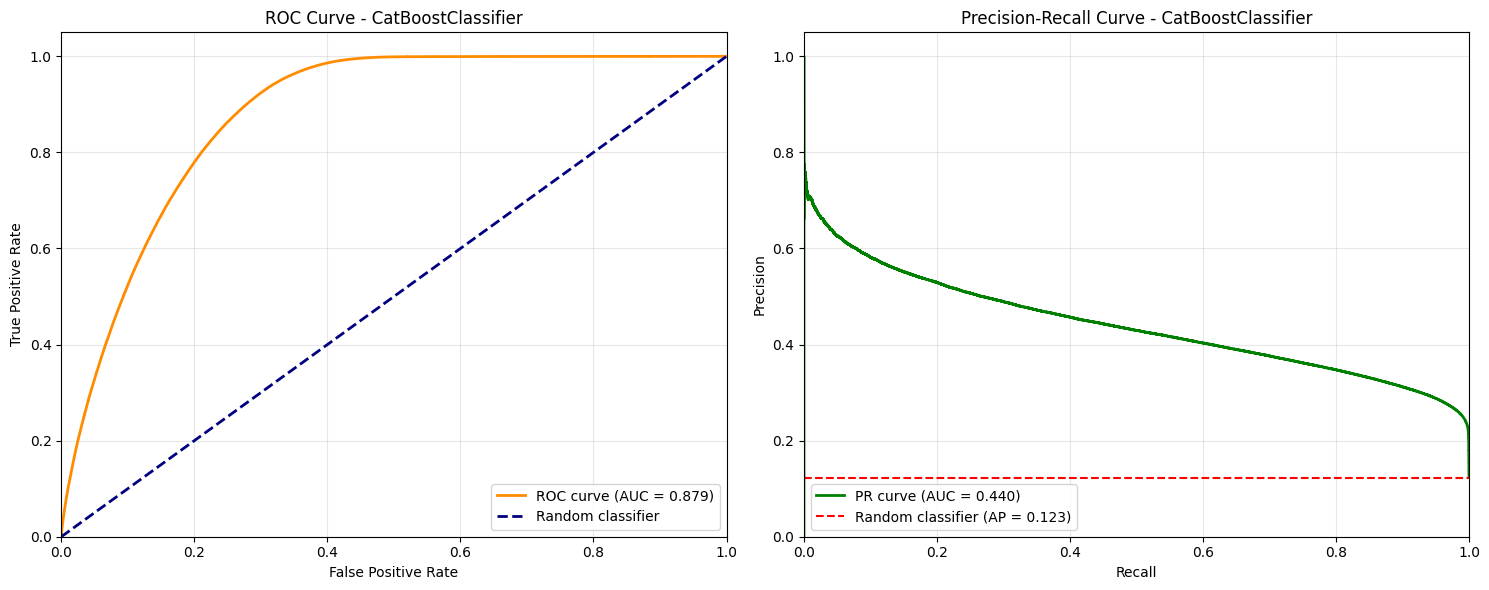

In [59]:
evaluate_model(cb_classifier, X_val, y_val, 'CatBoostClassifier', 'Validation')

f1 на валидации:

In [60]:
f1_score(y_val, cb_classifier.predict(X_val))

0.45659404234168666

In [21]:
from sklearn.metrics import make_scorer, f1_score

In [23]:
# 1. Создаем кастомную scorer для F1 класса "1"
f1_scorer = make_scorer(f1_score, average='binary', pos_label=1)

# 2. Параметры для Random Search (пример для XGBoost)
xgb_param_dist = {
    'scale_pos_weight': [1, 3, 5, 10, 20],  # Вариации от рассчитанного веса
    'max_depth': [3, 4, 5, 6, 7],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2],
    'learning_rate': [0.01, 0.05, 0.1]
}

In [22]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

In [29]:
# 4. Запуск Random Search (на примере XGBoost)
xgb_base = XGBClassifier(random_state=42, use_label_encoder=False, enable_categorical=True, eval_metric='logloss')
xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=50,  # Количество комбинаций
    scoring=f1_scorer,  # Целевая метрика!
    cv=3,  # 3-х фолд для скорости
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [30]:
xgb_search.fit(X_train, y_train)
print(f"Best XGB F1: {xgb_search.best_score_:.3f}")
print(f"Best params: {xgb_search.best_params_}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits


/home/daniil/Documents/2025-ITMO-ML-project/ml-project-env/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [01:01:22] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/daniil/Documents/2025-ITMO-ML-project/ml-project-env/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [01:01:22] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/daniil/Documents/2025-ITMO-ML-project/ml-project-env/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [01:01:23] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/daniil/Documents/2025-ITMO-ML-project/ml-project-env/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [01:01:23] WARNING: /workspace/src/learner.cc:790: 
Par

Best XGB F1: 0.475
Best params: {'subsample': 0.9, 'scale_pos_weight': 3, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}


In [31]:
print(f"Best XGB F1: {xgb_search.best_score_:.3f}")
print(f"Best params: {xgb_search.best_params_}")

Best XGB F1: 0.475
Best params: {'subsample': 0.9, 'scale_pos_weight': 3, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}


In [23]:
from lightgbm import LGBMClassifier

In [26]:
f1_scorer = make_scorer(f1_score, average='binary', pos_label=1)

In [27]:
# 1. Рассчитайте базовый вес для класса 1
#scale_pos_weight_value = np.sum(y_train == 0) / np.sum(y_train == 1)

# 2. Определите итоговую сетку параметров
param_distributions = {
    # Параметры баланса (используйте ОДИН из двух, закомментируйте второй)
    #'scale_pos_weight': [scale_pos_weight_value * mult for mult in [0.7, 1.0, 1.5, 2.0, 3.0, 5.0]],
    'is_unbalance': [True],
    
    # Параметры сложности
    'num_leaves': [15, 31, 63, 127],
    'max_depth': [3, 5, 7, -1],
    'min_child_samples': [10, 20, 40, 100],
    'reg_alpha': [0, 0.01, 0.1, 0.5],
    'reg_lambda': [0, 0.01, 0.1, 0.5],
    
    # Параметры обучения
    'learning_rate': [0.01, 0.03, 0.05, 0.07],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

In [28]:
lgb_base = LGBMClassifier(
    random_state=42,
    n_estimators=1000,  # Задайте достаточно большое число
    verbose=-1          # Отключите логи LightGBM во время поиска
)

lgb_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_distributions,
    n_iter=50,           # Количество случайных комбинаций
    scoring=f1_scorer,   # Целевая метрика - F1 для класса 1
    cv=3,                # Стратифицированная 3-фолд CV
    n_jobs=-1,           # Использовать все ядра
    verbose=1,           # Показывать прогресс
    random_state=42
)

# 5. Запустите поиск (используйте X_train, y_train)
lgb_search.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    #early_stopping_rounds=50,  # Ранняя остановка для каждой комбинации
    #verbose=False
)

# 6. Выведите лучшие результаты
print(f"Best F1 (class 1) from CV: {lgb_search.best_score_:.4f}")
print(f"Best parameters: {lgb_search.best_params_}")

# 7. Оцените лучшую модель на валидации
best_lgb = lgb_search.best_estimator_

Fitting 3 folds for each of 50 candidates, totalling 150 fits


KeyboardInterrupt: 

In [ ]:
print(f"Best F1 (class 1) from CV: {lgb_search.best_score_:.4f}")
print(f"Best parameters: {lgb_search.best_params_}")

In [29]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import classification_report, accuracy_score

# Функции calculate_auc_scores и plot_roc_pr_curves (предполагается, что они определены)
# Если их нет, см. реализацию в конце ответа.
# from your_module import calculate_auc_scores, plot_roc_pr_curves

def evaluate_model(model, X_val, y_val, model_name, data_name):
    """Evaluates model on X_val data with y_val labels as ground truth."""
    preds = model.predict(X_val)

    print(f'Accuracy score of {model_name} on {data_name}: {accuracy_score(y_val, preds):.3f}')

    print(f'Classification report on {data_name}')
    print(classification_report(y_val, preds))

    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_val)[:, 1]
    else:
        y_scores = model.decision_function(X_val)

    roc_auc, pr_auc = calculate_auc_scores(y_scores, y_val)

    print(f'AUC-ROC score of {model_name} on {data_name}: {roc_auc:.3f}')
    print(f'AUC-PR score of {model_name} on {data_name}: {pr_auc:.3f}')

    plot_roc_pr_curves(y_scores, y_val, model_name)




Training XGBoost Baseline Model...


/home/daniil/Documents/2025-ITMO-ML-project/ml-project-env/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [03:22:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



>>> XGBoost Baseline Results <<<

--- Performance on TRAIN set ---
Accuracy score of XGBoost Baseline on train: 0.802
Classification report on train
              precision    recall  f1-score   support

           0       0.96      0.81      0.88   2190250
           1       0.35      0.73      0.48    307254

    accuracy                           0.80   2497504
   macro avg       0.65      0.77      0.68   2497504
weighted avg       0.88      0.80      0.83   2497504

AUC-ROC score of XGBoost Baseline on train: 0.870
AUC-PR score of XGBoost Baseline on train: 0.408


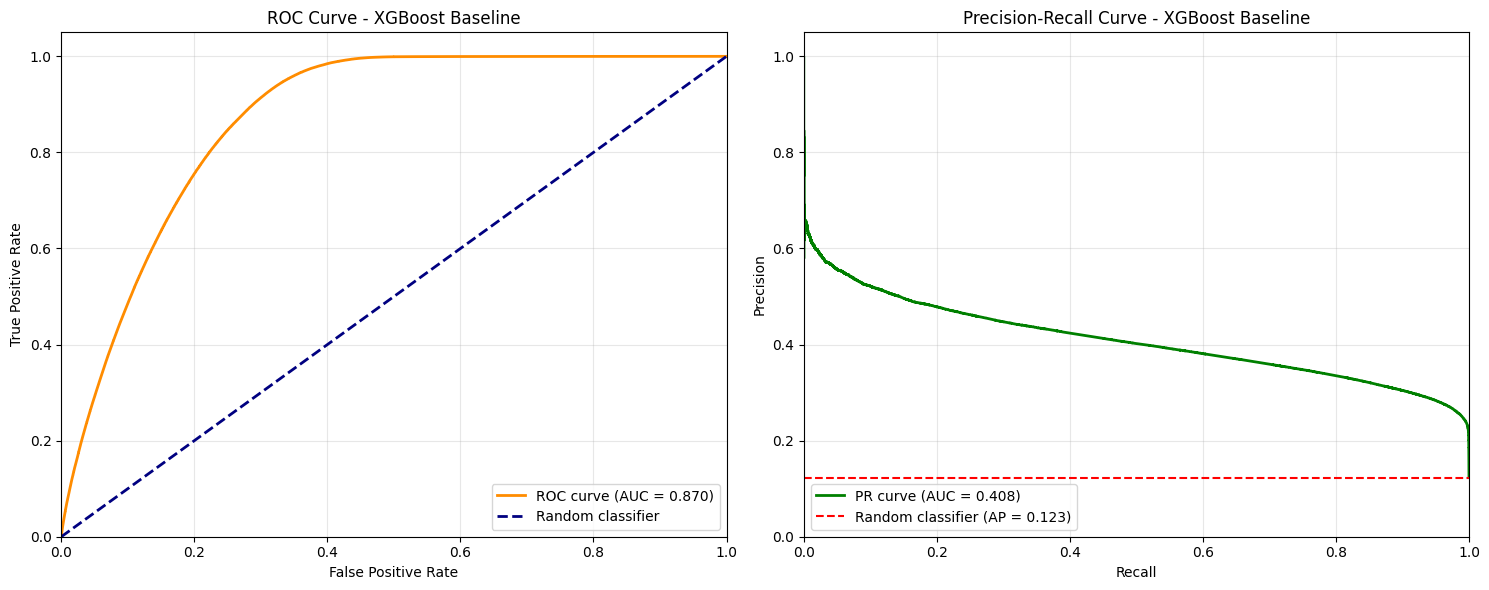


--- Performance on VALIDATION set ---
Accuracy score of XGBoost Baseline on validation: 0.801
Classification report on validation
              precision    recall  f1-score   support

           0       0.96      0.81      0.88   2192359
           1       0.35      0.73      0.47    307641

    accuracy                           0.80   2500000
   macro avg       0.65      0.77      0.68   2500000
weighted avg       0.88      0.80      0.83   2500000

AUC-ROC score of XGBoost Baseline on validation: 0.869
AUC-PR score of XGBoost Baseline on validation: 0.406


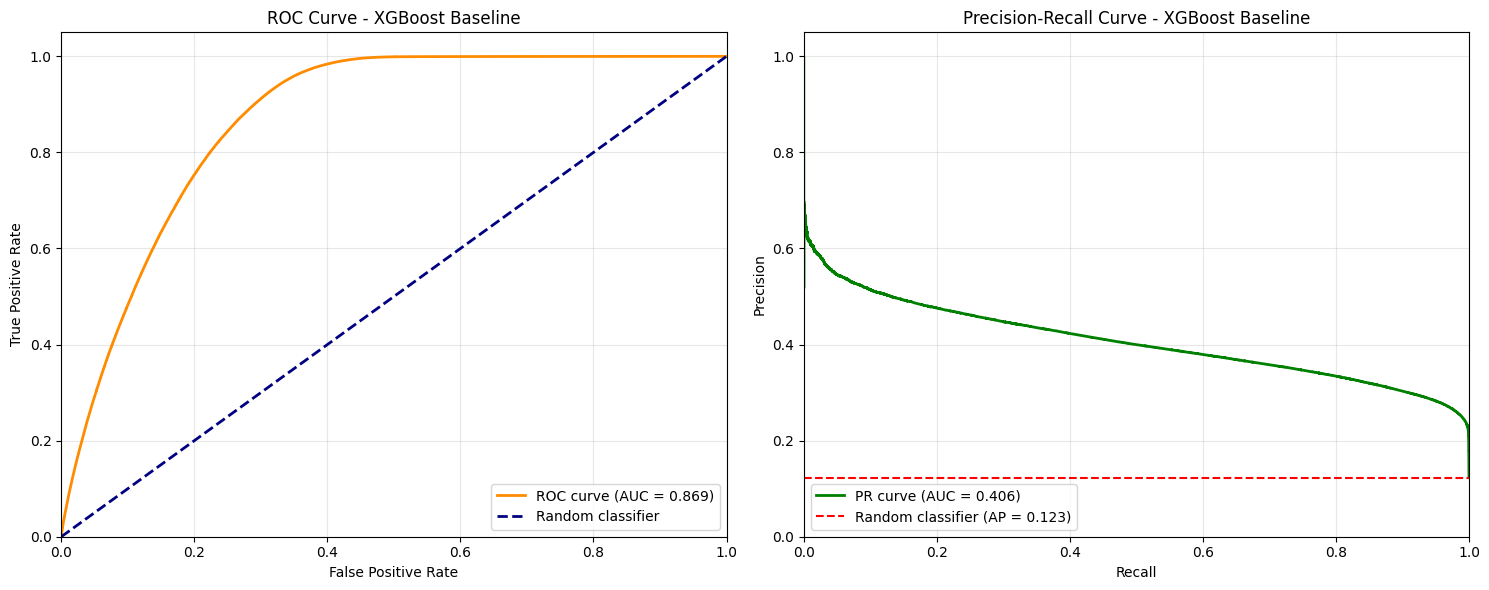

In [33]:
# 1. Обучение XGBoost
print("=" * 60)
print("Training XGBoost Baseline Model...")
print("=" * 60)

xgb_model = xgb.XGBClassifier(
    subsample=0.9,
    scale_pos_weight=3,
    min_child_weight=3,
    max_depth=5,
    learning_rate=0.1,
    gamma=0,
    colsample_bytree=0.8,
    random_state=42,

    eval_metric='logloss',
    
    enable_categorical=True,  # Ключевой параметр для категорий
    use_label_encoder=False   # Отключаем внутренний LabelEncoder
)

xgb_model.fit(
    X_train, 
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("\n>>> XGBoost Baseline Results <<<")
print("\n--- Performance on TRAIN set ---")
evaluate_model(xgb_model, X_train, y_train, "XGBoost Baseline", "train")
print("\n--- Performance on VALIDATION set ---")
evaluate_model(xgb_model, X_val, y_val, "XGBoost Baseline", "validation")

Посмотрим теперь на CatBoost:

In [ ]:
from catboost import CatBoostClassifier, Pool
import numpy as np

# Рассчитайте вес для положительного класса (класс "1")
scale_pos_weight_value = np.sum(y_train == 0) / np.sum(y_train == 1)

# 1. Определите сетку параметров (пример с "Базовой" сеткой)
param_distributions = {
    #'scale_pos_weight': [scale_pos_weight_value * mult for mult in [1, 2, 3, 5]],
    #'auto_class_weights': 'Balanced',
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5, 7],
    'learning_rate': [0.03, 0.05, 0.07],
    'random_strength': [0.5, 1, 2],
    'rsm': [0.8, 0.9, 1.0],
    'subsample': [0.8, 0.9],
    'grow_policy': ['SymmetricTree']
}

# 2. Создайте Pool-объекты для эффективной работы с категориальными признаками
train_pool = Pool(X_train, y_train, cat_features=categorical_features)
val_pool = Pool(X_val, y_val, cat_features=categorical_features)

# 3. Инициализируйте базовую модель
model = CatBoostClassifier(
    auto_class_weights='Balanced',
    iterations=500, # Укажите достаточно большое число
    random_seed=42,
    verbose=100,     # Логи каждые 100 итераций
    early_stopping_rounds=100, # Критически важно для долгого обучения
    task_type='CPU'  # Укажите 'GPU' для ускорения, если доступно
)

# 4. Запустите встроенный randomized_search
search_result = model.randomized_search(
    param_distributions,
    X=train_pool,
    cv=3,            # 3-фолд кросс-валидация
    n_iter=20,       # Количество случайных комбинаций для проверки
    partition_random_seed=42,
    calc_cv_statistics=True,
    search_by_train_test_split=True, # Рекомендуется для больших данных[citation:1]
    verbose=True,
    plot=True        # Построит график в Jupyter[citation:1]
)

In [ ]:
search_result.params

### Тюненый XGBoost против Catboost с балансом классов:

Сделаем новый train / val, для приблежения к размерам полной выборки:

In [61]:
data_train, data_val = train_test_split(data_train_full, test_size=0.1, stratify=data_train_full['Response'])

In [62]:
preprocessor_params = fit_preprocessor(data_train)

In [63]:
train_processed = apply_preprocessor(data_train, preprocessor_params, is_train=True)
val_processed = apply_preprocessor(data_val, preprocessor_params, is_train=False)

In [64]:
X_train['Age_Group'] = X_train['Age_Group'].astype(int)
X_val['Age_Group'] = X_val['Age_Group'].astype(int)

In [65]:
X_train['Premium_Group'] = X_train['Premium_Group'].astype(int)
X_val['Premium_Group'] = X_val['Premium_Group'].astype(int)

CatBoost:

In [66]:
cb_classifier = CatBoostClassifier(cat_features=categorical_features, auto_class_weights='Balanced', iterations=1000, early_stopping_rounds=100)

In [67]:
cb_classifier.fit(X_train, y_train, verbose=50)

Learning rate set to 0.29085
0:	learn: 0.5076116	total: 808ms	remaining: 13m 27s
50:	learn: 0.4074824	total: 48.4s	remaining: 15m 1s
100:	learn: 0.4020683	total: 1m 36s	remaining: 14m 14s
150:	learn: 0.3994342	total: 2m 24s	remaining: 13m 30s
200:	learn: 0.3979743	total: 3m 14s	remaining: 12m 53s
250:	learn: 0.3967973	total: 4m 7s	remaining: 12m 17s
300:	learn: 0.3958377	total: 5m	remaining: 11m 37s
350:	learn: 0.3949700	total: 5m 54s	remaining: 10m 55s
400:	learn: 0.3942163	total: 6m 48s	remaining: 10m 10s
450:	learn: 0.3935026	total: 7m 42s	remaining: 9m 23s
500:	learn: 0.3929022	total: 8m 35s	remaining: 8m 33s
550:	learn: 0.3922928	total: 9m 33s	remaining: 7m 47s
600:	learn: 0.3917558	total: 10m 28s	remaining: 6m 56s
650:	learn: 0.3912151	total: 11m 20s	remaining: 6m 4s
700:	learn: 0.3907216	total: 12m 16s	remaining: 5m 14s
750:	learn: 0.3902178	total: 13m 9s	remaining: 4m 21s
800:	learn: 0.3897873	total: 13m 57s	remaining: 3m 28s
850:	learn: 0.3893687	total: 14m 47s	remaining: 2m 3

In [68]:
pred_proba = cb_classifier.predict_proba(X_val)

In [76]:
max_f1 = 0
best_treshold = 0

for treshold in np.linspace(0, 1, 100):
    pred = (pred_proba[:, 1] > treshold).astype(int)
    f1 = f1_score(y_val, pred)
    if (f1 > max_f1):
        best_treshold = treshold
        max_f1 = f1
        

In [77]:
print(f'For CatBoost best f1-score: {max_f1:.2f} with treshold: {best_treshold:.2f}')

For CatBoost best f1-score: 0.49 with treshold: 0.71


XGBoost:

In [78]:
xgb_model = xgb.XGBClassifier(
    subsample=0.9,
    scale_pos_weight=3,
    min_child_weight=3,
    max_depth=5,
    learning_rate=0.1,
    gamma=0,
    colsample_bytree=0.8,
    random_state=42,

    eval_metric='logloss',
    
    enable_categorical=True,  # Ключевой параметр для категорий
    use_label_encoder=False   # Отключаем внутренний LabelEncoder
)

xgb_model.fit(
    X_train, 
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)


/home/daniil/Documents/2025-ITMO-ML-project/ml-project-env/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [13:35:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [79]:
pred_proba_xgb = xgb_model.predict_proba(X_val)

In [82]:
pred_proba_xgb[:5]

array([[9.9897283e-01, 1.0271770e-03],
       [5.3040218e-01, 4.6959782e-01],
       [9.9814641e-01, 1.8535666e-03],
       [9.9912632e-01, 8.7367021e-04],
       [4.5362246e-01, 5.4637754e-01]], dtype=float32)

In [83]:
max_f1_xgb = 0
best_treshold_xgb = 0

for treshold in np.linspace(0, 1, 100):
    pred = (pred_proba_xgb[:, 1] > treshold).astype(int)
    f1 = f1_score(y_val, pred)
    if (f1 > max_f1_xgb):
        best_treshold_xgb = treshold
        max_f1_xgb = f1

In [84]:
print(f'For XGBoost best f1-score: {max_f1_xgb:.2f} with treshold: {best_treshold_xgb:.2f}')

For XGBoost best f1-score: 0.47 with treshold: 0.51


CatBoost выдал качество лучше, время инференса было сопоставленно в предыдущей тетрадке ($\sim 1860$ ms для CatBoost против $\sim 740$ ms для XGBoost).

In [85]:
import pickle

In [87]:
with open('catboost_model.pkl', 'wb') as f:
    pickle.dump(cb_classifier, f)

with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

In [89]:
res_df = pd.DataFrame({'Model': ['catboost_model.pkl', 'xgboost_model.pkl'], 'Best f1': [max_f1, max_f1_xgb], 'Treshold': [best_treshold, best_treshold_xgb]})

In [90]:
res_df.to_csv('Treshlods.csv')